#クロスバリデーション(MFCC, Loudness無)＋最大値

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_200ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1_file = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').max()
        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2_file = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df_test_file = max_df2_file.groupby('label').max()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    #print(train_df)
    #print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    #print(f"元の訓練データ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    print(f"テストデータ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz','Loudness_sma3', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"訓練データの正解ラベル数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"テストデータの正解ラベル数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')
    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
訓練データ行数: 475
テストデータ行数: 120
訓練データの正解ラベル数: 475
テストデータの正解ラベル数: 120
[10, 9, 10, 10, 10, 10, 9, 10, 9, 8, 9, 9, 7]
                          filepath        filename  Delirium  Prediction
0   voice_csv_200ms\ID30_200ms.csv  ID30_200ms.csv         0           0
5   voice_csv_200ms\ID35_200ms.csv  ID35_200ms.csv         0           0
9   voice_csv_200ms\ID39_200ms.csv  ID39_200ms.csv         0           0
12  voice_csv_200ms\ID42_200ms.csv  ID42_200ms.csv         0           0
16  voice_csv_200ms\ID46_200ms.csv  ID46_200ms.csv         1           0
30  voice_csv_200ms\ID60_200ms.csv  ID60_200ms.csv         0           0
33  voice_csv_200ms\ID63_200ms.csv  ID63_200ms.csv         1           0
41  voice_csv_200ms\ID71_200ms.csv  ID71_200ms.csv         1           0
45  voice_csv_200ms\ID75_200ms.csv  ID75_200ms.csv         1           0
53  voice_csv_200ms\ID83_200ms.csv  ID83_200ms.csv         1           0
60  voice_csv_200ms\ID90_200ms.csv  ID90_200ms

平均

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
0
1
0
1
0
0
0
0
0
1
1
0
0
1
0
0
0
0
0
1
0
1
1
0
0
0
0
0
1
0
0
0
1
1
1
0
1
1
0
1
1
1
1
1
1
1
1
1
0
0
1
1
        label  start  end  Loudness_sma3  alphaRatio_sma3  \
0     answer1    NaN  NaN       0.364651       -19.728282   
1    answer10    NaN  NaN       0.256897       -22.967945   
2     answer2    NaN  NaN       0.399049       -16.945661   
3     answer3    NaN  NaN       0.364947       -19.278692   
4     answer4    NaN  NaN       0.332307       -20.839752   
..        ...    ...  ...            ...              ...   
470   answer5    NaN  NaN       0.381886        -5.721938   
471   answer6    NaN  NaN       0.793042       -12.346788   
472   answer7    NaN  NaN       0.668580       -13.143902   
473   answer8    NaN  NaN       0.798909       -11.532240   
474   answer9    NaN  NaN       0.676303       -12.442322   

     hammarbergIndex_sma3  slope0-500_sma3  slope500-1500_sma3  \
0               27.571145        -0.039248           -0.

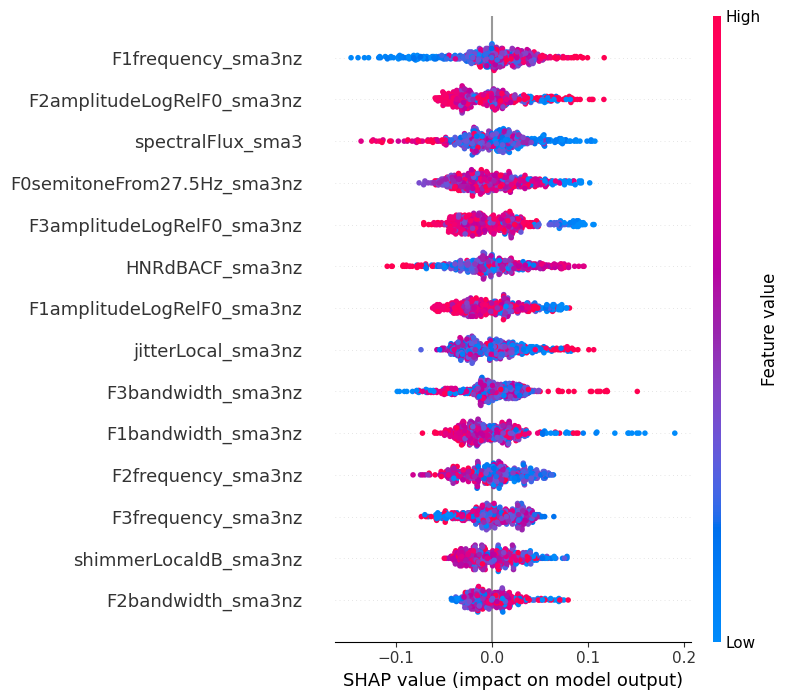

間違えたファイルの (start, end) リスト: [(68, 78), (87, 95), (104, 113)]
SHAP Values (error) の形状: (27, 14, 2)


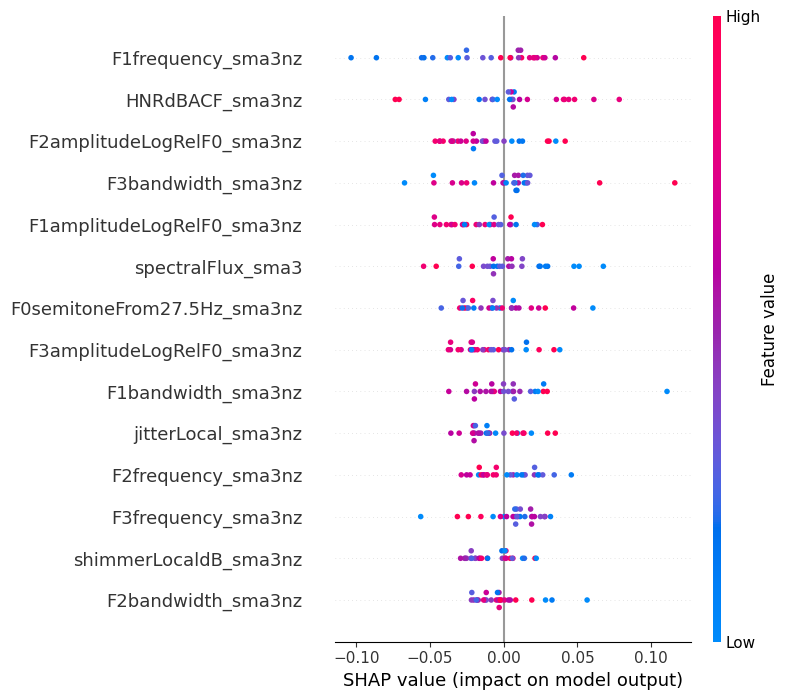

--- Fold 2 ---
訓練ファイル数: 52, テストファイル数: 13
0
0
1
0
0
0
0
0
0
1
0
1
1
0
0
0
0
1
1
1
0
0
0
0
0
1
1
0
0
1
1
1
0
1
1
1
0
1
1
1
1
1
1
1
1
1
0
0
1
1
1
1
        label  start  end  Loudness_sma3  alphaRatio_sma3  \
0     answer1    NaN  NaN       0.225189       -24.083739   
1    answer10    NaN  NaN       0.163906       -26.766194   
2     answer2    NaN  NaN       0.149689       -27.579897   
3     answer3    NaN  NaN       0.292445       -19.131310   
4     answer4    NaN  NaN       0.304846       -19.172319   
..        ...    ...  ...            ...              ...   
466   answer5    NaN  NaN       0.700021        -6.885373   
467   answer6    NaN  NaN       0.370006       -14.607556   
468   answer7    NaN  NaN       0.445311       -12.384051   
469   answer8    NaN  NaN       0.361199       -17.357807   
470   answer9    NaN  NaN       0.365667       -16.058672   

     hammarbergIndex_sma3  slope0-500_sma3  slope500-1500_sma3  \
0               33.600908        -0.080582           -0.

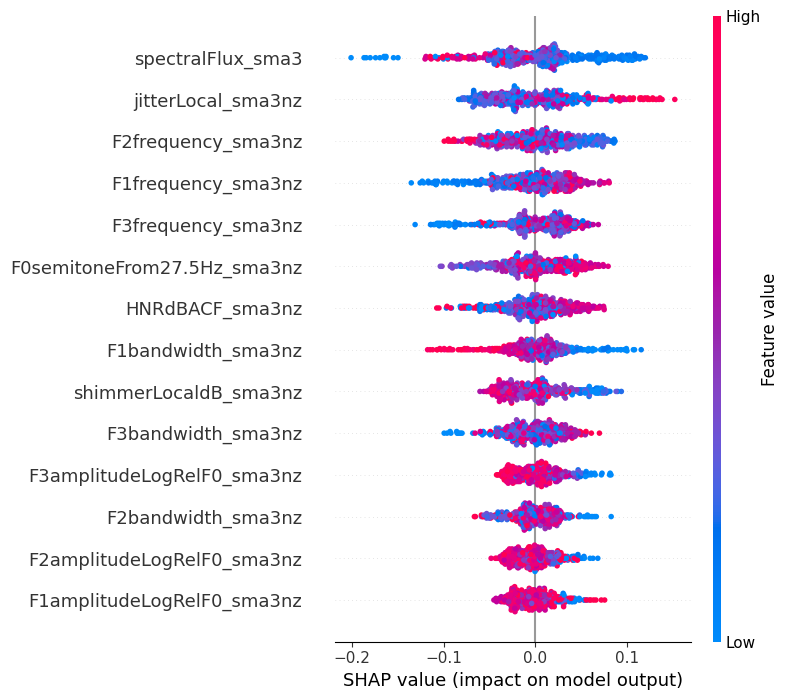

間違えたファイルの (start, end) リスト: [(10, 18), (104, 114)]
SHAP Values (error) の形状: (18, 14, 2)


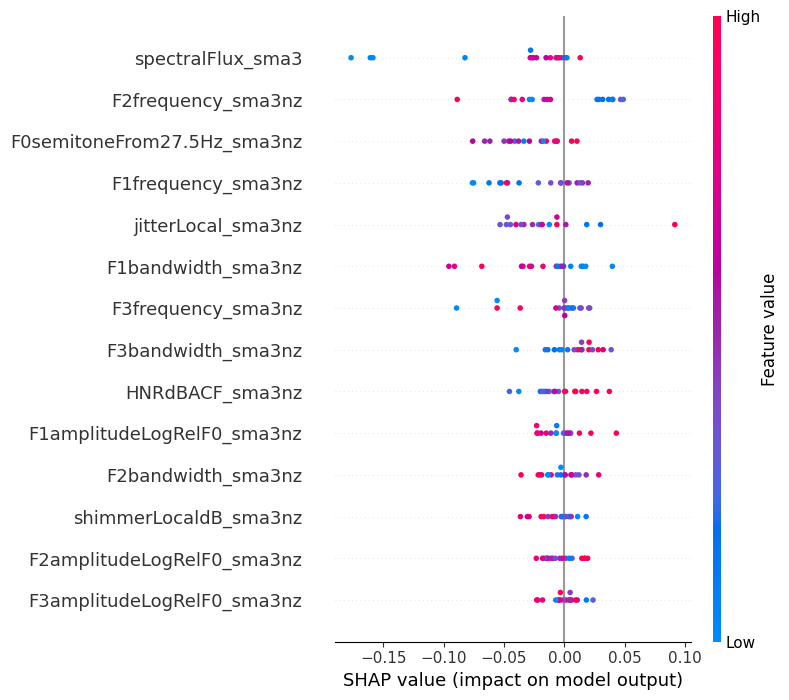

--- Fold 3 ---
訓練ファイル数: 52, テストファイル数: 13
0
0
1
0
1
0
0
0
0
0
0
0
1
1
1
0
1
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
0
1
1
1
1
0
1
1
1
1
1
1
1
1
1
0
1
1
1
1
        label  start  end  Loudness_sma3  alphaRatio_sma3  \
0     answer1    NaN  NaN       0.225189       -24.083739   
1    answer10    NaN  NaN       0.163906       -26.766194   
2     answer2    NaN  NaN       0.149689       -27.579897   
3     answer3    NaN  NaN       0.292445       -19.131310   
4     answer4    NaN  NaN       0.304846       -19.172319   
..        ...    ...  ...            ...              ...   
472   answer5    NaN  NaN       0.700021        -6.885373   
473   answer6    NaN  NaN       0.370006       -14.607556   
474   answer7    NaN  NaN       0.445311       -12.384051   
475   answer8    NaN  NaN       0.361199       -17.357807   
476   answer9    NaN  NaN       0.365667       -16.058672   

     hammarbergIndex_sma3  slope0-500_sma3  slope500-1500_sma3  \
0               33.600908        -0.080582           -0.

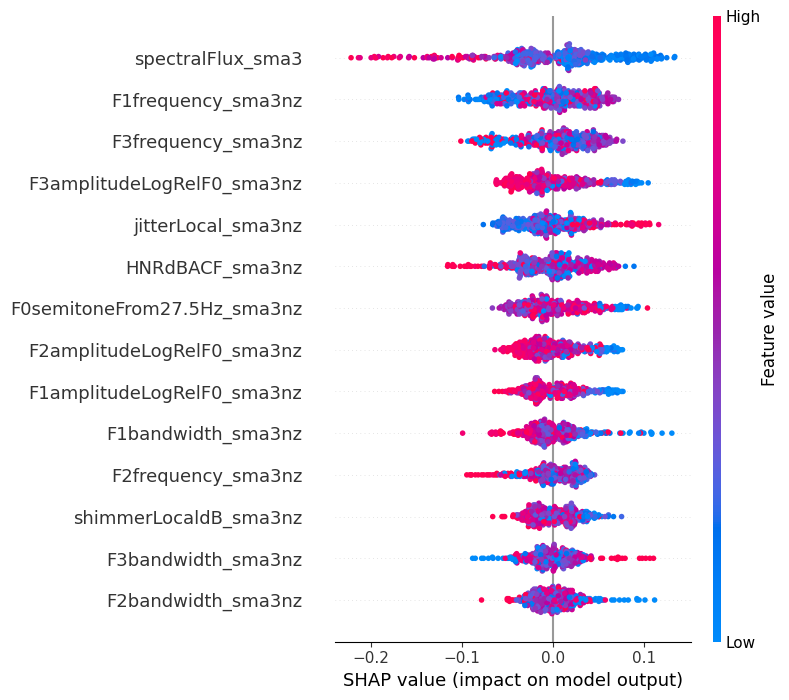

間違えたファイルの (start, end) リスト: [(27, 36), (55, 64), (72, 82), (82, 91), (91, 99), (109, 118)]
SHAP Values (error) の形状: (54, 14, 2)


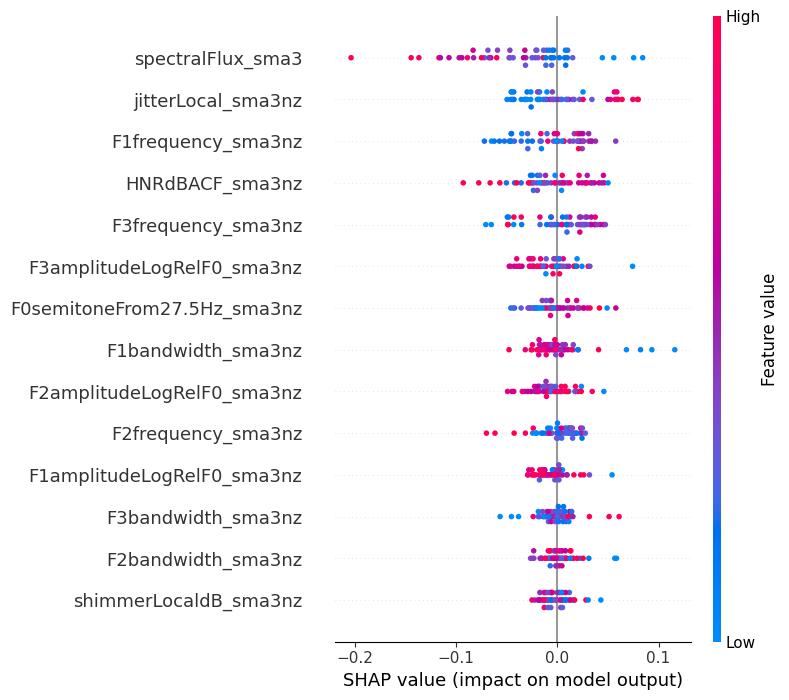

--- Fold 4 ---
訓練ファイル数: 52, テストファイル数: 13
0
0
1
0
0
0
0
0
0
0
0
1
1
0
1
0
1
0
0
0
0
1
0
1
1
0
0
0
1
0
0
0
1
1
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
        label  start  end  Loudness_sma3  alphaRatio_sma3  \
0     answer1    NaN  NaN       0.225189       -24.083739   
1    answer10    NaN  NaN       0.163906       -26.766194   
2     answer2    NaN  NaN       0.149689       -27.579897   
3     answer3    NaN  NaN       0.292445       -19.131310   
4     answer4    NaN  NaN       0.304846       -19.172319   
..        ...    ...  ...            ...              ...   
473   answer5    NaN  NaN       0.700021        -6.885373   
474   answer6    NaN  NaN       0.370006       -14.607556   
475   answer7    NaN  NaN       0.445311       -12.384051   
476   answer8    NaN  NaN       0.361199       -17.357807   
477   answer9    NaN  NaN       0.365667       -16.058672   

     hammarbergIndex_sma3  slope0-500_sma3  slope500-1500_sma3  \
0               33.600908        -0.080582           -0.

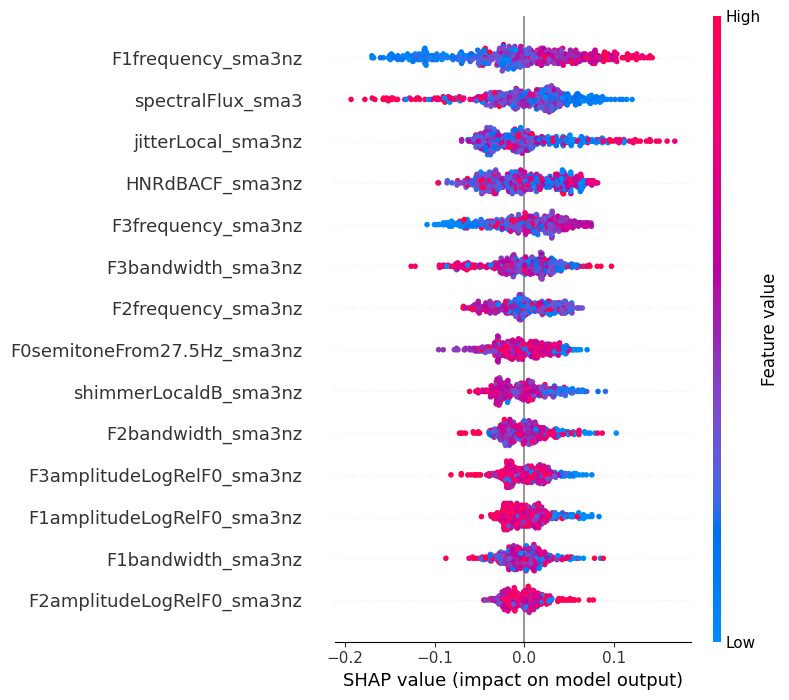

間違えたファイルの (start, end) リスト: [(10, 20), (48, 58), (82, 91), (91, 100)]
SHAP Values (error) の形状: (38, 14, 2)


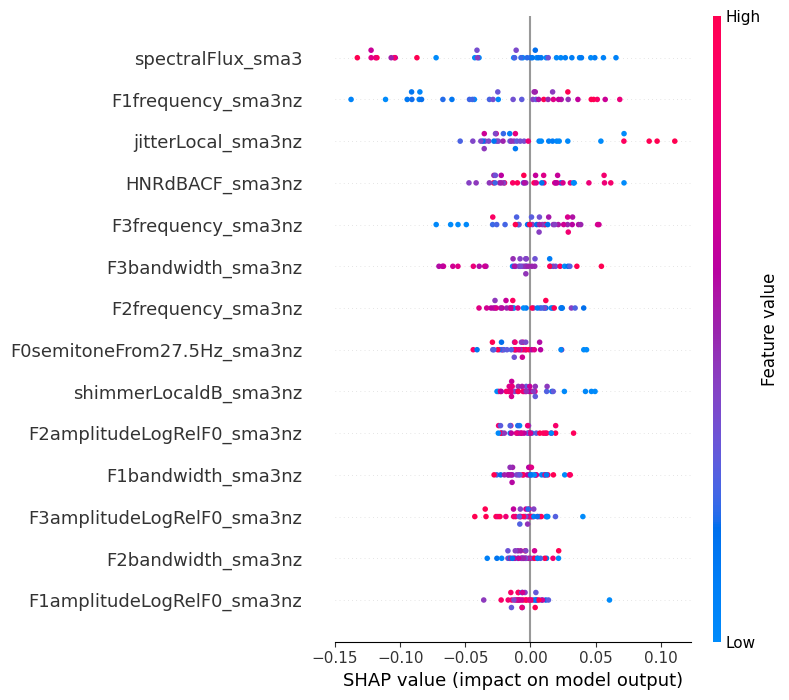

--- Fold 5 ---
訓練ファイル数: 52, テストファイル数: 13
0
0
1
0
1
0
0
0
0
0
0
1
0
1
0
0
0
1
0
1
1
0
0
0
0
1
0
1
0
0
1
1
1
0
1
1
1
0
1
1
1
1
1
1
1
0
0
1
1
1
1
1
        label  start  end  Loudness_sma3  alphaRatio_sma3  \
0     answer1    NaN  NaN       0.225189       -24.083739   
1    answer10    NaN  NaN       0.163906       -26.766194   
2     answer2    NaN  NaN       0.149689       -27.579897   
3     answer3    NaN  NaN       0.292445       -19.131310   
4     answer4    NaN  NaN       0.304846       -19.172319   
..        ...    ...  ...            ...              ...   
474   answer5    NaN  NaN       0.700021        -6.885373   
475   answer6    NaN  NaN       0.370006       -14.607556   
476   answer7    NaN  NaN       0.445311       -12.384051   
477   answer8    NaN  NaN       0.361199       -17.357807   
478   answer9    NaN  NaN       0.365667       -16.058672   

     hammarbergIndex_sma3  slope0-500_sma3  slope500-1500_sma3  \
0               33.600908        -0.080582           -0.

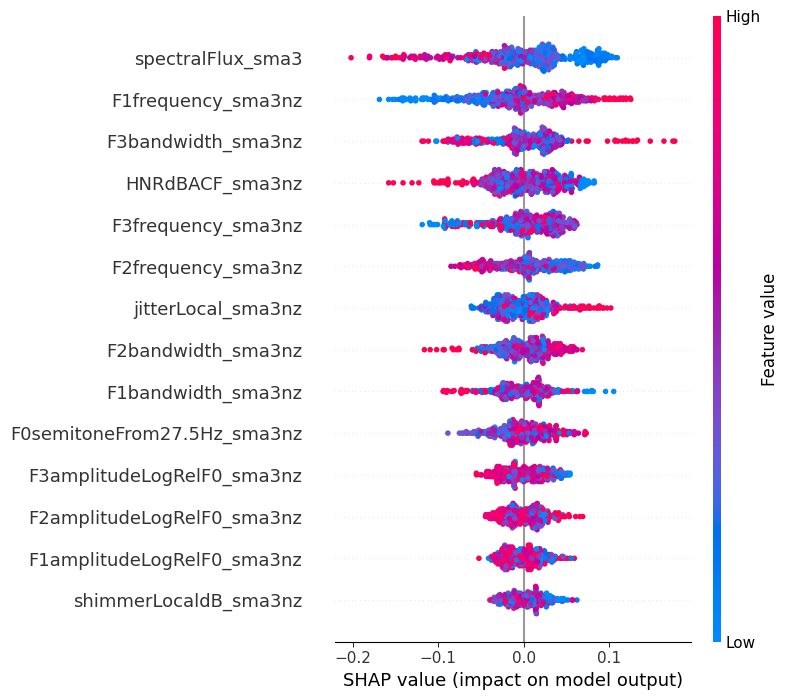

間違えたファイルの (start, end) リスト: []
該当するエラーはありませんでした。
5つのFoldのファイル単位での平均正解率：0.6615

5つのFoldのファイル単位での性能のばらつき(標準偏差)：0.1427


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import shap

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_20ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1 = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()
        
        max_df1_file = max_df1.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')

        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').mean()
        #print(max_df_train_file)

        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2 = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df2_file = max_df2.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df2_file[col] = pd.to_numeric(max_df2_file[col], errors='coerce')

        max_df_test_file = max_df2_file.groupby('label').mean()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    print(train_df)
    print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    print(f"テストデータ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3','Loudness_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"元の訓練データ行数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元のテストデータ行数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    #NaNの数をカウント
    print(y_train.isnull().sum())

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_true = y_test
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    #print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append([majority_vote, start_idx, end_idx])
        start_idx = end_idx

    first_column_list = [item[0] for item in file_predictions]

    #print(file_predictions)

    y_test_files = test_files['Delirium'].values

    #print(y_test_files)

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=first_column_list)

    print(test_files_copy)

    correct_files = np.sum(np.array(first_column_list) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, first_column_list)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train) 

    #shap_values 全体の形状を確認 (おそらく (479, 14, 2))
    print(f"SHAP Values (全体) の形状: {shap_values.shape}")

    #せん妄ありのSHAP値だけをスライス ---
    shap_values_class1 = shap_values[:, :, 1]

    #スライスした後の形状を確認 (これで (479, 14) になるはず)
    print(f"SHAP Values (Class 1) の形状: {shap_values_class1.shape}")
    #print(f"X_train の形状: {X_train.shape}")

    #スライスした shap_values_class1 を渡す
    shap.summary_plot(shap_values_class1, X_train)

    #予測が0で正解が1の場合
    shap.initjs()

    misclassified_indices = []

    for pred, true_label, full_item in zip(first_column_list, y_test_files, file_predictions):

        if (pred == 0) & (true_label == 1):
            start_idx = full_item[1]
            end_idx = full_item[2]

            misclassified_indices.append((start_idx, end_idx))

    print(f"間違えたファイルの (start, end) リスト: {misclassified_indices}")

    #間違えたセグメントを格納するための空のリスト
    X_test_errors_list = []

    for start, end in misclassified_indices:
        #X_test から start から end までのセグメントをスライス
        #(iloc は X_test がDataFrameの場合。Numpy配列なら X_test[start:end] )
        segment = X_test.iloc[start:end] 
        X_test_errors_list.append(segment)

    #抜き出したセグメントをすべて結合
    if X_test_errors_list:
        X_test_errors = pd.concat(X_test_errors_list) #DataFrameの場合
        
        #これで初めて X_test_errors に対して SHAP が実行できる
        shap_values_errors = explainer.shap_values(X_test_errors)
        
        print(f"SHAP Values (error) の形状: {shap_values_errors.shape}")
        shap.summary_plot(shap_values_errors[:, :, 1], X_test_errors)
    else:
        print("該当するエラーはありませんでした。")

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])a
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

SHAP Values (全体) の形状: (479, 14, 2)
SHAP Values (Class 1) の形状: (479, 14)
X_train の形状: (479, 14)


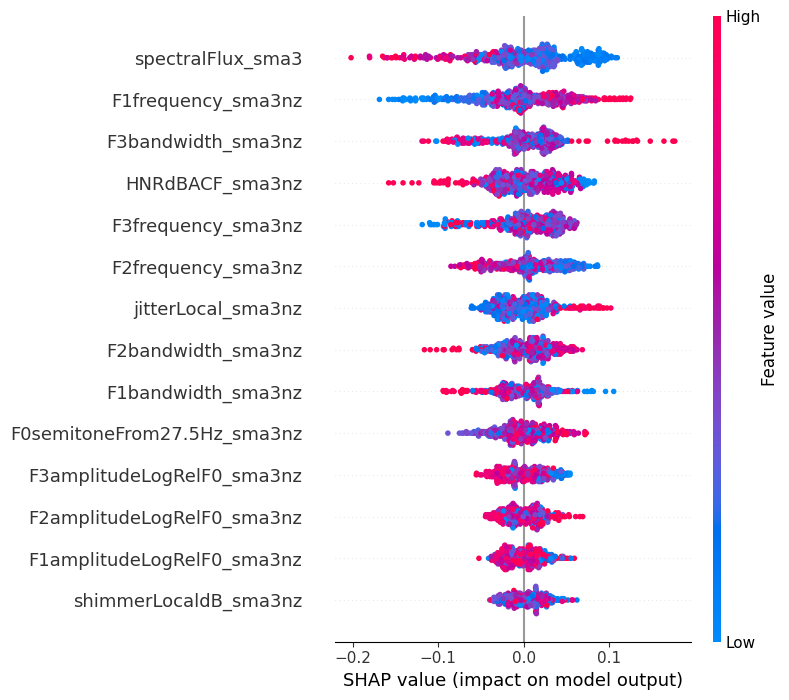

In [50]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train) 

# shap_values 全体の形状を確認 (おそらく (479, 14, 2))
print(f"SHAP Values (全体) の形状: {shap_values.shape}")

# --- Class 1 のSHAP値だけをスライス ---
shap_values_class1 = shap_values[:, :, 1]

# スライスした後の形状を確認 (これで (479, 14) になるはず)
print(f"SHAP Values (Class 1) の形状: {shap_values_class1.shape}")
print(f"X_train の形状: {X_train.shape}")


# --- summary_plot を実行 ---
# スライスした shap_values_class1 を渡す
shap.summary_plot(shap_values_class1, X_train)
#shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

結果の分析

SHAP Values (error) の形状: (16, 14, 2)
ID58, 68


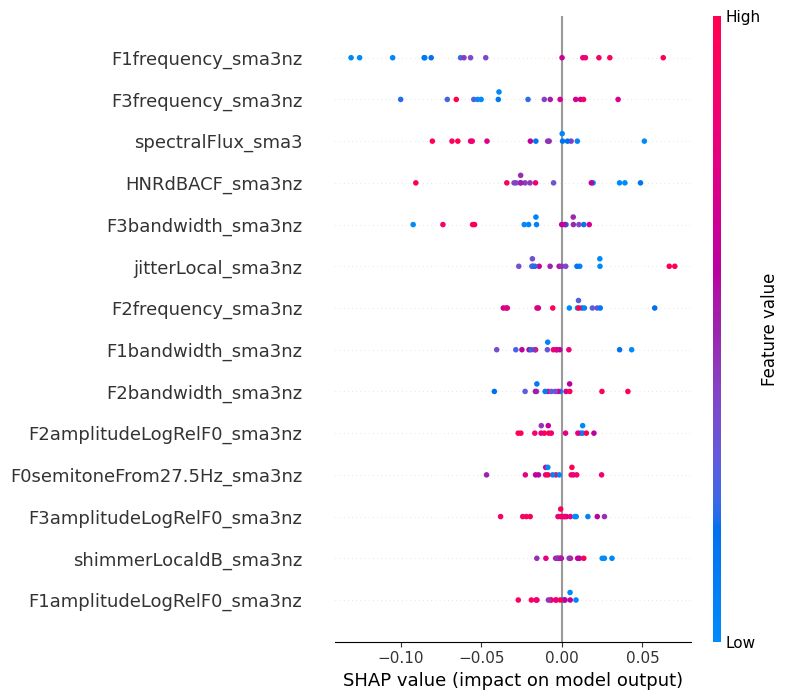

In [49]:
shap.initjs()

misclassified_mask = (y_pred == 0) & (y_true ==1)

X_test_errors = X_test[misclassified_mask]

y_test_errors = y_true[misclassified_mask]

shap_values_errors = explainer.shap_values(X_test_errors)

print(f"SHAP Values (error) の形状: {shap_values_errors.shape}")
print("ID58, 68")

shap.summary_plot(shap_values_errors[:, :, 1], X_test_errors)



In [51]:
# 'model' は学習済みのランダムフォレストモデル
print(f"モデルが認識しているクラスの順序: {model.classes_}")

モデルが認識しているクラスの順序: [0. 1.]


In [46]:
shap.force_plot(
    explainer.expected_value[1],     # クラス1の基準値
    shap_values_errors[0, :, 1],     # 不正解1件目 の クラス1 SHAP値
    X_test_errors.iloc[0, :]         # 不正解1件目 の 元の値
)

標準偏差

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

pd.options.display.max_rows = None

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_20ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)
        
        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1 = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()
        
        max_df1_file = max_df1.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')

        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').std()

        #print(max_df_train_file)

        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2 = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df2_file = max_df2.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df2_file[col] = pd.to_numeric(max_df2_file[col], errors='coerce')

        max_df_test_file = max_df2_file.groupby('label').std()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    #print(train_df)
    #print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    print(f"テストデータ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3','Loudness_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"元の訓練データ行数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元のテストデータ行数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    #NaNの数をカウント
    #print(y_train.isnull().sum())

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])a
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
訓練データ行数: 475
テストデータ行数: 120
訓練データの正解ラベル数: 475
テストデータの正解ラベル数: 120
[10, 9, 10, 10, 10, 10, 9, 10, 9, 8, 9, 9, 7]
                        filepath       filename  Delirium  Prediction
0   voice_csv_20ms\ID30_20ms.csv  ID30_20ms.csv         0         0.0
5   voice_csv_20ms\ID35_20ms.csv  ID35_20ms.csv         0         0.0
9   voice_csv_20ms\ID39_20ms.csv  ID39_20ms.csv         0         0.0
12  voice_csv_20ms\ID42_20ms.csv  ID42_20ms.csv         0         0.0
16  voice_csv_20ms\ID46_20ms.csv  ID46_20ms.csv         1         0.0
30  voice_csv_20ms\ID60_20ms.csv  ID60_20ms.csv         0         0.0
33  voice_csv_20ms\ID63_20ms.csv  ID63_20ms.csv         1         0.0
41  voice_csv_20ms\ID71_20ms.csv  ID71_20ms.csv         1         0.0
45  voice_csv_20ms\ID75_20ms.csv  ID75_20ms.csv         1         0.0
53  voice_csv_20ms\ID83_20ms.csv  ID83_20ms.csv         1         0.0
60  voice_csv_20ms\ID90_20ms.csv  ID90_20ms.csv         1         0.0
61  voice